In [1]:
%%capture
!pip install scikit-network

In [4]:
import numpy as np
adj = np.array([[0,1,1,1,0], [1,0,0,0,1], [1,0,0,1,0], [1,0,1,0,1], [0,1,0,1,0]])
adj

array([[0, 1, 1, 1, 0],
       [1, 0, 0, 0, 1],
       [1, 0, 0, 1, 0],
       [1, 0, 1, 0, 1],
       [0, 1, 0, 1, 0]])

In [5]:
from scipy import sparse
adj = sparse.csr_matrix(adj)
adj

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (5, 5)>

In [6]:
from IPython.display import SVG
from sknetwork.visualization import visualize_graph

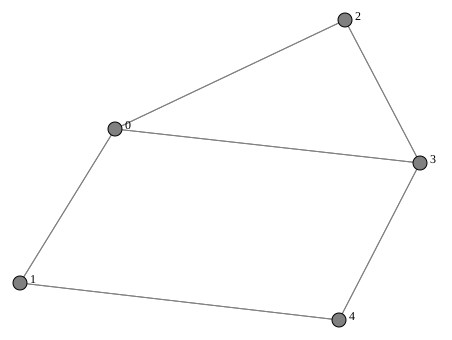

In [15]:
# display nodes by indices
n_nodes, _ = adj.shape
names = np.arange(n_nodes)
SVG(visualize_graph(adj, names = names))

In [16]:
# Case study
from sknetwork.data import karate_club
from sknetwork.classification import DiffusionClassifier

In [18]:
dataset = karate_club(metadata=True)
dataset

{'adjacency': <Compressed Sparse Row sparse matrix of dtype 'bool'
 	with 156 stored elements and shape (34, 34)>,
 'labels': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'position': array([[ 0.04, -0.33],
        [ 0.24, -0.15],
        [ 0.01, -0.01],
        [ 0.13, -0.28],
        [ 0.02, -0.64],
        [-0.08, -0.75],
        [ 0.04, -0.76],
        [ 0.21, -0.25],
        [ 0.08,  0.09],
        [-0.11,  0.23],
        [-0.13, -0.62],
        [-0.28, -0.4 ],
        [ 0.2 , -0.53],
        [ 0.08, -0.07],
        [ 0.23,  0.55],
        [ 0.06,  0.64],
        [-0.06, -1.  ],
        [ 0.32, -0.42],
        [ 0.15,  0.6 ],
        [ 0.19, -0.01],
        [ 0.27,  0.45],
        [ 0.39, -0.34],
        [-0.04,  0.61],
        [-0.26,  0.41],
        [-0.51,  0.14],
        [-0.49,  0.28],
        [-0.19,  0.68],
        [-0.28,  0.21],
        [-0.11,  0.12],
        [-0.17,  0.54],
        [ 0.22,  0.19],

In [21]:
adj = dataset.adjacency
position = dataset.position
labels = dataset.labels

In [22]:
classifier = DiffusionClassifier()
classifier.fit(adj, {node:labels[node] for node in [0, 1, 33]})

DiffusionClassifier(n_iter=10, centering=True, scale=5)

In [23]:
labels_pred = classifier.predict()

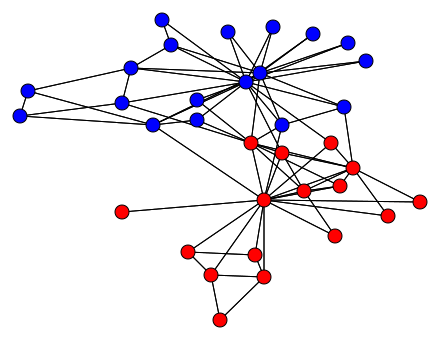

In [24]:
SVG(visualize_graph(adj, position, labels=labels_pred))

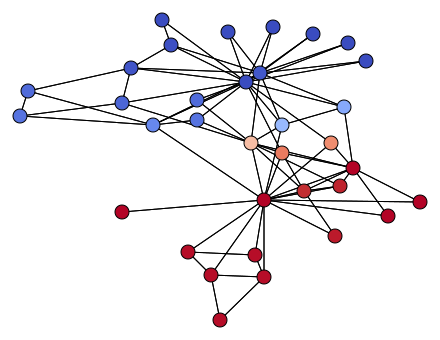

In [25]:
probs = classifier.predict_proba()
scores = probs[:, 1]
SVG(visualize_graph(adj, position, scores=scores))

In [29]:
from IPython.display import SVG
from scipy import sparse
import pandas as pd

from sknetwork.data import erdos_renyi, block_model, linear_digraph, cyclic_digraph,linear_graph, cyclic_graph, grid, albert_barabasi, watts_strogatz
from sknetwork.visualization import visualize_graph, visualize_bigraph

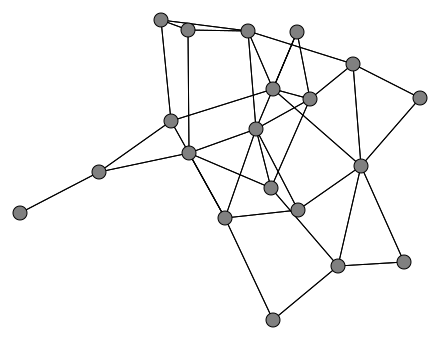

In [30]:
adj = erdos_renyi(20, 0.2)
image = visualize_graph(adj)
SVG(image)

In [42]:
graph = block_model([20, 25, 30], p_in=[0.5, 0.4, 0.3], p_out=0.03, metadata=True)
ajd = graph.adjacency
labels = graph.labels

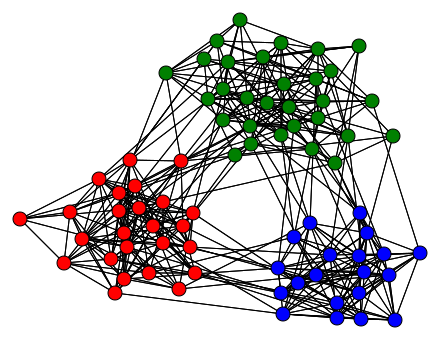

In [43]:
image = visualize_graph(ajd, labels=labels)
SVG(image)